In [2]:
import json

file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))


<class 'dict'>


In [3]:
messages = data["messages"]
print(len(messages))

716


In [4]:
import pandas as pd
df = pd.DataFrame(messages)
print(df.shape)
df.head()

(716, 30)


,id,type,date,date_unixtime,actor,actor_id,action,title,text,text_entities,...,height,file,file_size,thumbnail,thumbnail_file_size,media_type,mime_type,duration_seconds,file_name,poll
0,1,service,2025-05-09T08:17:33,1746775053,Sir Mapy,channel2696454823,create_channel,Sir Mapy,,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,message,2025-05-09T12:25:17,1746789917,NaN,NaN,NaN,NaN,"[Believers,\nPlease look at for these dates 17...","[{'type': 'plain', 'text': 'Believers, Please ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,message,2025-05-09T12:25:30,1746789930,NaN,NaN,NaN,NaN,"[Believers,\nIn light of the many warnings and...","[{'type': 'plain', 'text': 'Believers, In ligh...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,message,2025-05-09T12:25:46,1746789946,NaN,NaN,NaN,NaN,"[Believers,\nIn continuation of where I stoppe...","[{'type': 'plain', 'text': 'Believers, In cont...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,message,2025-05-09T13:03:14,1746792194,NaN,NaN,NaN,NaN,"Believers,\nWiki Cat's Market Cap and Supply d...","[{'type': 'plain', 'text': 'Believers, Wiki Ca...",...,800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
def extract_text(message):
    if isinstance(message, str):
        return message
    elif isinstance(message, list):
        return "".join([part.get("text", "") if isinstance(part, dict) else str(part) for part in message])
    else:
        return ""

df["clean_text"] = df["text"].apply(extract_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,,
1,"[Believers,\nPlease look at for these dates 17...","Believers,\nPlease look at for these dates 17,..."
2,"[Believers,\nIn light of the many warnings and...","Believers,\nIn light of the many warnings and ..."
3,"[Believers,\nIn continuation of where I stoppe...","Believers,\nIn continuation of where I stopped..."
4,"Believers,\nWiki Cat's Market Cap and Supply d...","Believers,\nWiki Cat's Market Cap and Supply d..."


In [6]:
df = df[df["clean_text"].str.strip() !=""]

In [7]:
print(df.shape)

(695, 31)


<Axes: title={'center': 'Messages per Day'}, xlabel='date'>

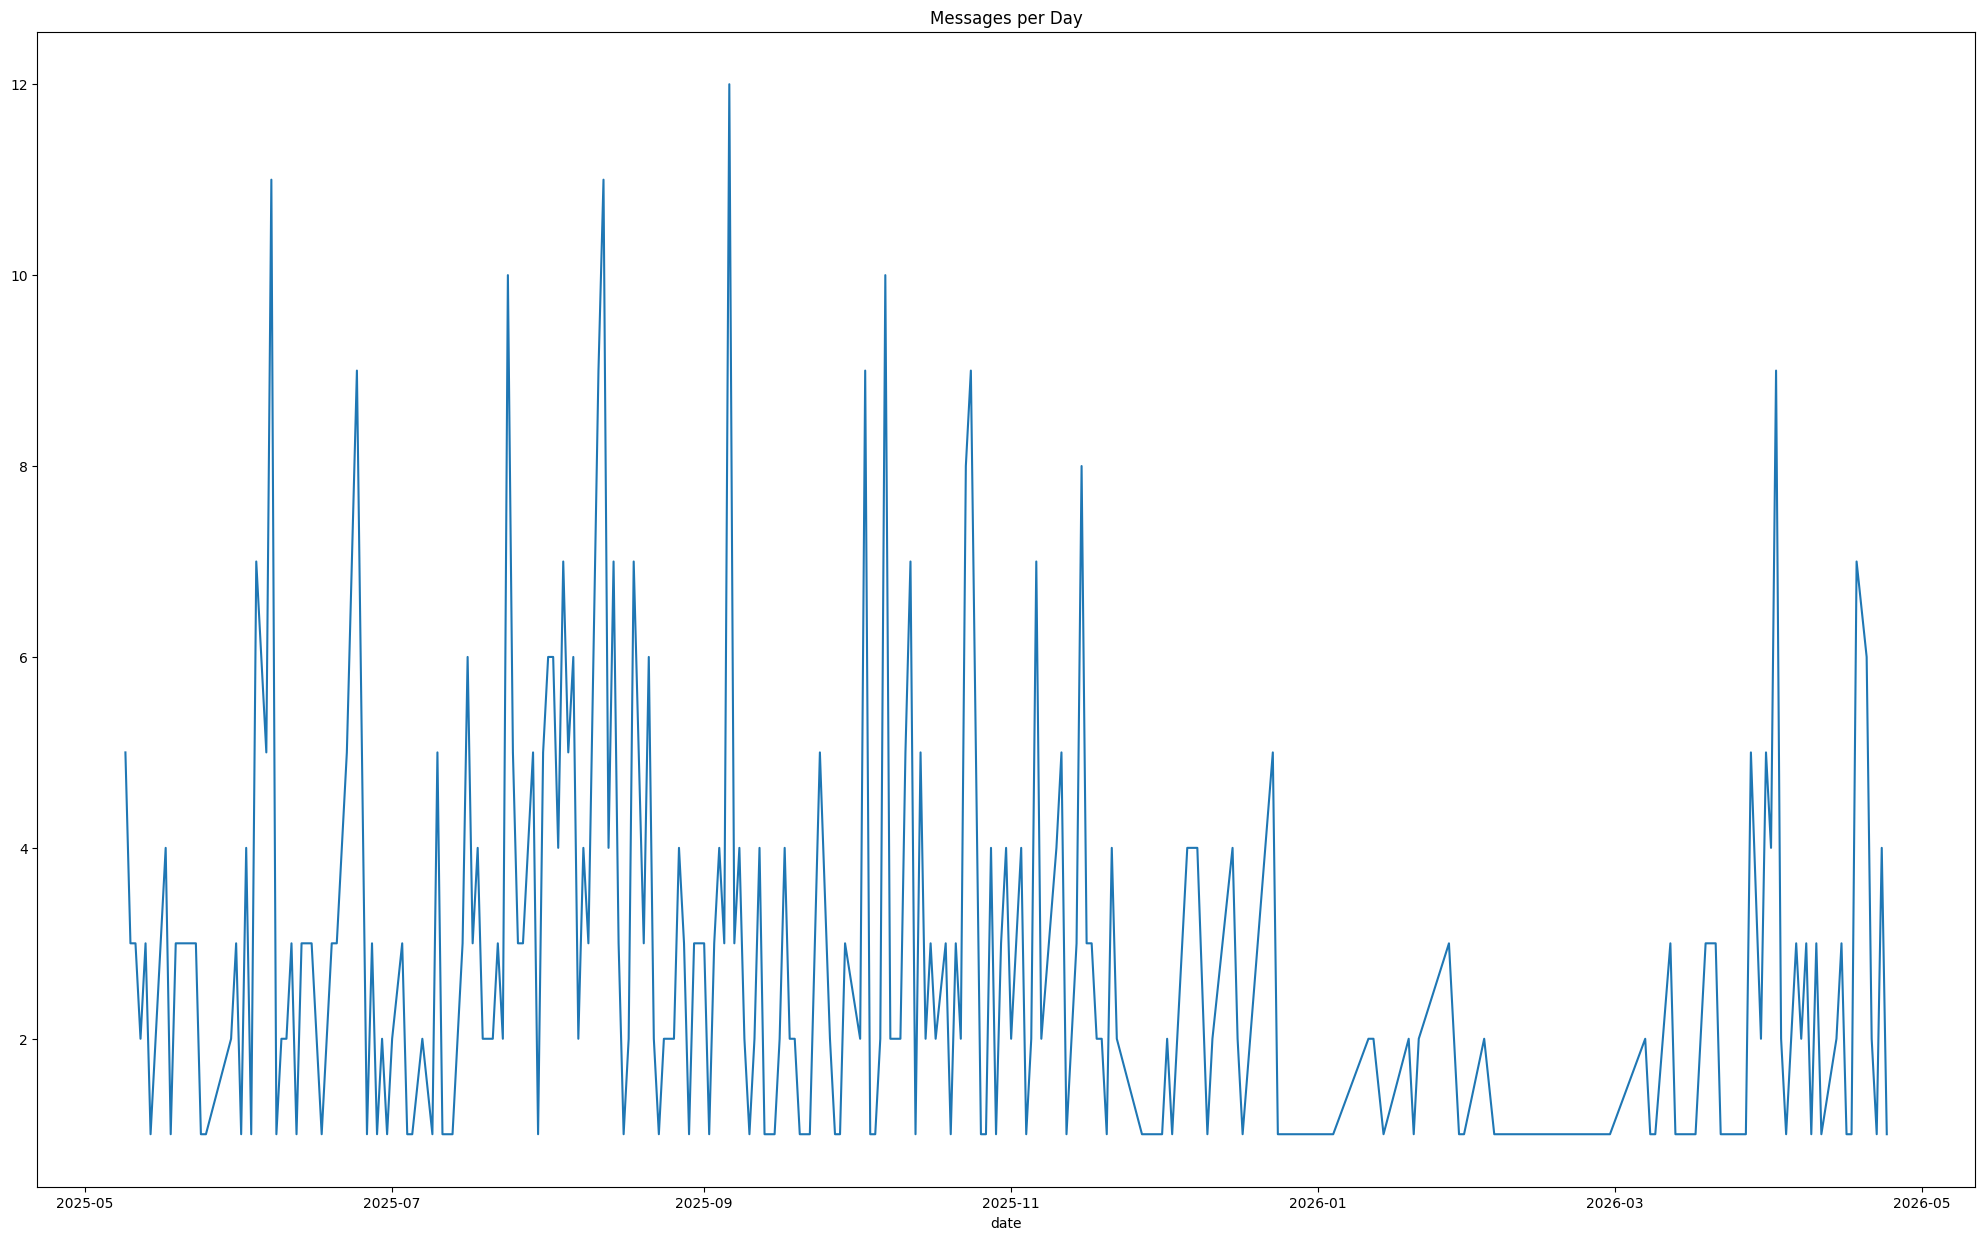

In [8]:
df["date"] = pd.to_datetime(df["date"])
messages_per_day = df.groupby(df["date"].dt.date).size()
messages_per_day.plot(figsize=(25,15),title="Messages per Day")

In [9]:
top_days = messages_per_day.sort_values(ascending=False).head(10)
top_days

date
2025-09-06    12
2025-06-07    11
2025-08-12    11
2025-10-07    10
2025-07-24    10
2026-04-02     9
2025-10-24     9
2025-06-24     9
2025-08-11     9
2025-10-03     9
dtype: int64

In [10]:
top_day = top_days.index[0]
spike_df = df[df["date"].dt.date == top_day]
spike_df[["clean_text"]]

,clean_text
341,"Happy weekend Believers, \n2 hours left to com..."
342,"From one Server Rack, we will own Data Centres..."
343,You don't build Goshen deep inside of Egypt. \...
344,"Over the week, Roqqu added us to a poll on wha..."
345,"SMC is a community of Believers, dedicated to ..."
346,"Another whale has offered to invest $20,000 in..."
347,"Another whale has offered to invest $10,000 in..."
348,We have finished downloaded the BNB Chain from...
349,2 whales and 1 Shark have offered to invest $2...
350,"There is just so many Dms, right now, sorry If..."


In [11]:
from collections import Counter 
import re
text = " ".join(df["clean_text"].dropna())
words = re.findall(r"\b\w+\b", 
                   text.lower())
Counter(words).most_common(40)

[('the', 1252),
 ('to', 1176),
 ('and', 766),
 ('we', 606),
 ('you', 552),
 ('i', 548),
 ('of', 546),
 ('a', 521),
 ('for', 496),
 ('is', 472),
 ('will', 408),
 ('on', 345),
 ('in', 333),
 ('with', 328),
 ('it', 314),
 ('that', 305),
 ('this', 305),
 ('are', 296),
 ('our', 284),
 ('smc', 270),
 ('be', 263),
 ('have', 263),
 ('peniwallet', 250),
 ('your', 239),
 ('believers', 226),
 ('as', 226),
 ('wiki', 226),
 ('cat', 226),
 ('god', 206),
 ('t', 204),
 ('all', 201),
 ('from', 190),
 ('not', 165),
 ('my', 161),
 ('can', 159),
 ('if', 148),
 ('000', 146),
 ('now', 143),
 ('at', 132),
 ('me', 128)]

In [12]:
stop_words = {
    "the","to","and","we","you","of","a","for","is","will","on","in","with",
    "it","that","this","are","be","have","your","as","all"
}

filtered_words = [word for word in words if word not in stop_words]

from collections import Counter
Counter(filtered_words).most_common(25)

[('i', 548),
 ('our', 284),
 ('smc', 270),
 ('peniwallet', 250),
 ('believers', 226),
 ('wiki', 226),
 ('cat', 226),
 ('god', 206),
 ('t', 204),
 ('from', 190),
 ('not', 165),
 ('my', 161),
 ('can', 159),
 ('if', 148),
 ('000', 146),
 ('now', 143),
 ('at', 132),
 ('me', 128),
 ('so', 128),
 ('update', 128),
 ('us', 127),
 ('wallet', 125),
 ('or', 122),
 ('app', 122),
 ('community', 121)]

In [13]:
import re
text = " ".join(df["clean_text"].dropna())
words = re.findall(r"\b\w+\b", 
                   text.lower())

In [14]:
import json 
file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

In [15]:
print(type(data))

<class 'dict'>


In [16]:
messages = data["messages"]

In [17]:
import pandas as pd
df = pd.DataFrame(messages)
print(df.shape)

(716, 30)


In [18]:
df["clean_text"] =
df["text"].astype(str)
df = df[df["clean_text"].str.strip() !=""]

SyntaxError: invalid syntax (2771595734.py, line 1)

In [ ]:
df["clean_text"] = df["text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]


In [ ]:
print(df.shape)

In [ ]:
df[["clean_text"]].head()

In [ ]:
import re
text = " ".join(df["clean_text"].dropna())
words = re.findall(r"\b\w+\b", 
                   text.lower())

In [ ]:
stop_words = {
    "the","to","and","we","you","of","a","for","is","will","on","in","with",
    "it","that","this","are","be","have","your","as","all"
}

filtered_words = [word for word in words if word not in stop_words]

In [ ]:
from collections import Counter
Counter(filtered_words).most_common(25)

In [ ]:
extra_stop_words = {
    "n","i","t","type","text","plain","from","not","my","can","now","me","at","if","us",
    "000"
}

all_stop_words = stop_words.union(extra_stop_words)

filtered_words_clean = [word for word in words if word not in all_stop_words]

Counter(filtered_words_clean).most_common(20)


In [ ]:
!pip install textblob

In [ ]:
import sys !{sys.executable} -m pip install textblob

In [ ]:
!{sys.executable} -m pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
def get_sentiment(text):
    try:
        return TextBlob(text).sentiment.polarity
    except:
        return 0

In [ ]:
df["sentiment"] = df["clean_text"].apply(get_sentiment)

In [ ]:
df[["clean_text", "sentiment"]].head()

In [ ]:
def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment"].apply(sentiment_label)

In [19]:
df["sentiment_label"].value_counts()

KeyError: 'sentiment_label'

In [20]:
df["sentiment_label"] = df["sentiment"].apply(sentiment_label)

KeyError: 'sentiment'

In [21]:
df["sentiment"] = df["clean_text"].apply(get_sentiment)

KeyError: 'clean_text'

In [22]:
print(df.columns)
print("get_sentiment exists:", "get_sentiment" in globals())

Index(['id', 'type', 'date', 'date_unixtime', 'actor', 'actor_id', 'action',
       'title', 'text', 'text_entities', 'edited', 'edited_unixtime', 'from',
       'from_id', 'reactions', 'forwarded_from', 'forwarded_from_id', 'photo',
       'photo_file_size', 'width', 'height', 'file', 'file_size', 'thumbnail',
       'thumbnail_file_size', 'media_type', 'mime_type', 'duration_seconds',
       'file_name', 'poll'],
      dtype='str')
get_sentiment exists: False


In [24]:
from textblob import TextBlob

df["clean_text"] = df["text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]

def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

# Create sentiment column
df["sentiment"] = df["clean_text"].apply(get_sentiment)

def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment"].apply(sentiment_label)

print(df.shape)
print(df["sentiment_label"].value_counts())

(695, 33)
sentiment_label
Positive    327
Neutral     310
Negative     58
Name: count, dtype: int64


In [25]:
sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()
sentiment_daily.plot(title="Average Sentiment Over Time")

AttributeError: Can only use .dt accessor with datetimelike values

In [26]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [27]:
sentiment_daily = df.groupby(df["date"].dt.date)
["sentiment"].mean()
sentiment_daily.plot(title="Aveage Sentiment Over Time")

AttributeError: 'list' object has no attribute 'mean'

<Axes: title={'center': 'Average Sentiment Over Time'}, xlabel='date'>

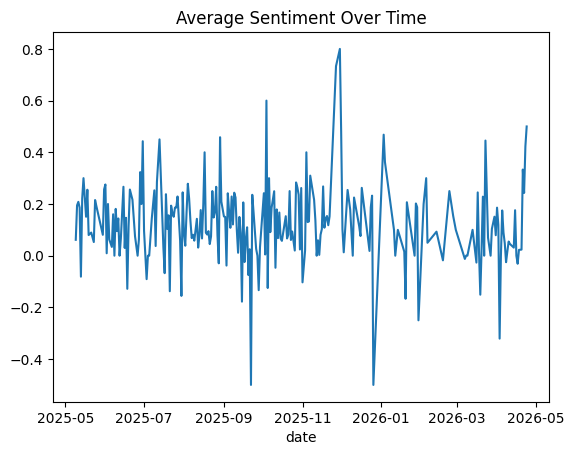

In [28]:
sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()
sentiment_daily.plot(title="Average Sentiment Over Time")

In [29]:
messages_daily = df.groupby(df["date"].dt.date).size()

fig, ax1 = plt.subplots()

ax1.plot(messages_daily, label="Messages", color="blue")
ax1.set_ylabel("Message Count")

ax2 = ax1.twinx()
ax2.plot(sentiment_daily, label="Sentiment", color="orange")
ax2.set_ylabel("Sentiment")

plt.title("Community Activity vs Sentiment")
plt.show()

NameError: name 'plt' is not defined

In [30]:
import matplotlib.pyplot as plt

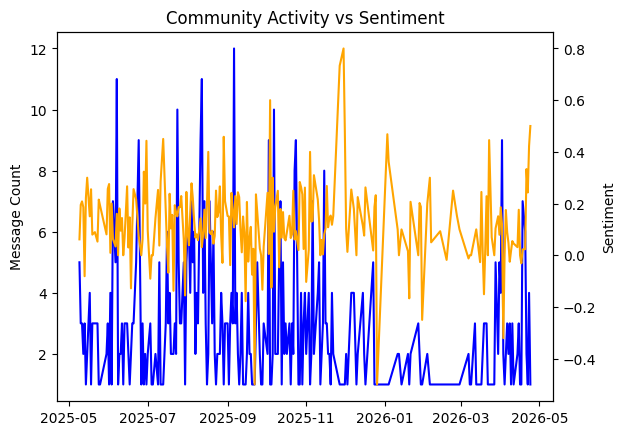

In [31]:
messages_daily = df.groupby(df["date"].dt.date).size()

fig, ax1 = plt.subplots()

ax1.plot(messages_daily, label="Messages", color="blue")
ax1.set_ylabel("Message Count")

ax2 = ax1.twinx()
ax2.plot(sentiment_daily, label="Sentiment", color="orange")
ax2.set_ylabel("Sentiment")

plt.title("Community Activity vs Sentiment")
plt.show()

<Axes: title={'center': 'Filtered Activity vs Sentiment'}, xlabel='date'>

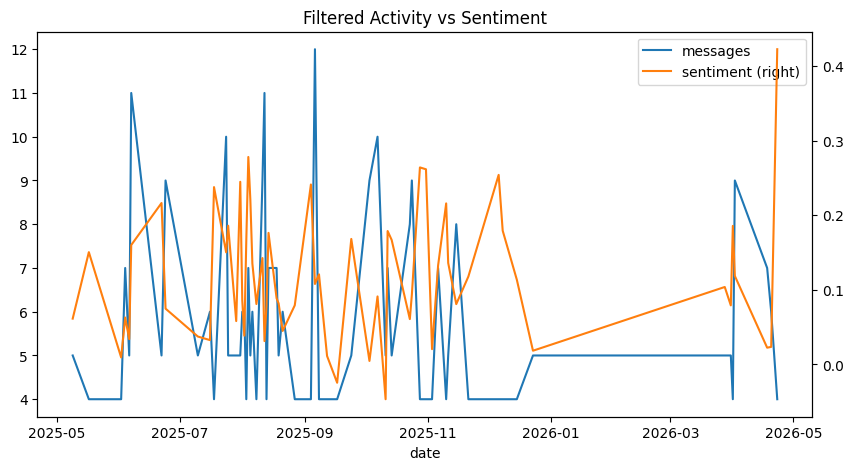

In [32]:
combined = pd.DataFrame({
    "messages": messages_daily,
    "sentiment": sentiment_daily
})

combined = combined[combined["messages"] > 3]

combined.plot(secondary_y="sentiment", figsize=(10,5), title="Filtered Activity vs Sentiment")

In [34]:
df_april_2026 = df[
    (df["date"].dt.month == 4) &
    (df["date"].dt.year == 2026)]
df_april_2026[["clean_text", "sentiment"]].head(24)

,clean_text,sentiment
654,Happy new month Believers. This is my birth mo...,0.468182
655,Just did N100 airtime with Wiki Cat on Penirem...,0.000000
656,OTC is coming to Swap with Bread. \n\nBuy/Sell...,0.075216
657,"If everyone has $1,000,000 in their peniwallet...",0.200000
658,"Good morning Believers,\nI am forever grateful...",0.433333
659,The issues of unwanted tokens will be resolved...,-0.061012
660,Sometimes you will just be there obeying God’s...,0.233333
661,Decided to stop at chicken republic. First mea...,-0.175000
662,Peniremit will allow you spend WKC and other t...,-0.062500
663,Living my life off WKC via Peniremit.\n\nApril...,0.200000


In [35]:
from collections import Counter
import re

text_april = " ".join(df_april_2026["clean_text"])
words_april = re.findall(r"\b\w+\b", text_april.lower())

Counter(words_april).most_common(24)

[('to', 85),
 ('and', 72),
 ('the', 60),
 ('of', 51),
 ('a', 43),
 ('is', 40),
 ('will', 40),
 ('i', 40),
 ('n', 36),
 ('we', 35),
 ('for', 35),
 ('you', 32),
 ('in', 31),
 ('with', 29),
 ('that', 27),
 ('have', 26),
 ('this', 25),
 ('wiki', 25),
 ('cat', 25),
 ('on', 24),
 ('our', 24),
 ('it', 23),
 ('be', 21),
 ('peniremit', 19)]

In [2]:
stop_words = {
    "the","to","and","we","you","of","a","for","is","will","on","in","with",
    "it","that","this","are","be","have","your","as","all","i","our","or",
    "so","has","one","an","at","by","from"
}

words_april_2026_clean = [
    word for word in words_april if word not in stop_words
]

Counter(words_april_clean).most_common(20)

NameError: name 'words_april' is not defined

In [1]:
import re

text_april = " ".join(df_april_2026["clean_text"])
words_april = re.findall(r"\b\w+\b", text_april.lower())

NameError: name 'df_april_2026' is not defined

In [2]:
df_april_2026 = df[
    (df["date"].dt.month == 4) &
    (df["date"].dt.year == 2026)
    ]

NameError: name 'df' is not defined

In [3]:
df_april_2026 = df[
    (df["date"].dt.month == 4) & 
    (df["date"].dt.year == 2026)
]


NameError: name 'df' is not defined

In [1]:
import json

file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)


In [2]:
import pandas as pd
df = pd.DataFrame(data["messages"])

In [3]:
df["clean_text"] = df["text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]

In [4]:
df["date"] = pd.to_datetime(df["date"],errors="coerce")

In [5]:
df_april_2026 = df[
    (df["date"].dt.month == 4) & 
    (df["date"].dt.year == 2026)
]


In [6]:
df_april_2026.head()

,id,type,date,date_unixtime,actor,actor_id,action,title,text,text_entities,...,file,file_size,thumbnail,thumbnail_file_size,media_type,mime_type,duration_seconds,file_name,poll,clean_text
654,664,message,2026-04-01 09:06:02,1775030762,NaN,NaN,NaN,NaN,Happy new month Believers. This is my birth mo...,"[{'type': 'plain', 'text': 'Happy new month Be...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Happy new month Believers. This is my birth mo...
655,665,message,2026-04-01 10:43:11,1775036591,NaN,NaN,NaN,NaN,Just did N100 airtime with Wiki Cat on Penirem...,"[{'type': 'plain', 'text': 'Just did N100 airt...",...,(File not included. Change data exporting sett...,1630457.0,(File not included. Change data exporting sett...,8172.0,video_file,video/mp4,37.0,IMG_3783.MP4,NaN,Just did N100 airtime with Wiki Cat on Penirem...
656,666,message,2026-04-01 12:56:34,1775044594,NaN,NaN,NaN,NaN,OTC is coming to Swap with Bread. \n\nBuy/Sell...,"[{'type': 'plain', 'text': 'OTC is coming to S...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OTC is coming to Swap with Bread. \n\nBuy/Sell...
657,667,message,2026-04-01 13:17:21,1775045841,NaN,NaN,NaN,NaN,"If everyone has $1,000,000 in their peniwallet...","[{'type': 'plain', 'text': 'If everyone has $1...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"If everyone has $1,000,000 in their peniwallet..."
658,668,message,2026-04-02 09:47:34,1775119654,NaN,NaN,NaN,NaN,"Good morning Believers,\nI am forever grateful...","[{'type': 'plain', 'text': 'Good morning Belie...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Good morning Believers,\nI am forever grateful..."


In [7]:
from collections import Counter
import re

text_april = " ".join(df_april_2026["clean_text"])
words_april = re.findall(r"\b\w+\b", text_april.lower())

stop_words = {
    "the","to","and","we","you","of","a","for","is","will","on","in","with",
    "it","that","this","are","be","have","your","as","all","i","our","or",
    "so","has","one","an","at","by","from","n","t"
}

words_april_clean = [
    word for word in words_april if word not in stop_words
]

Counter(words_april_clean).most_common(20)

[('wiki', 25),
 ('cat', 25),
 ('peniremit', 19),
 ('my', 14),
 ('000', 14),
 ('god', 14),
 ('believers', 13),
 ('can', 13),
 ('wallet', 11),
 ('not', 11),
 ('now', 11),
 ('wkc', 10),
 ('smc', 10),
 ('they', 10),
 ('type', 10),
 ('text', 10),
 ('was', 10),
 ('just', 9),
 ('transfer', 9),
 ('community', 9)]

In [8]:
df_april_2026.groupby("sentiment_label").size()

KeyError: 'sentiment_label'

In [9]:
df_april_2026 = df[
    (df["date"].dt.month == 4) & 
    (df["date"].dt.year == 2026)
]


In [10]:
df_april_2026.groupby("sentiment_label").size()

KeyError: 'sentiment_label'

In [11]:
from textblob import TextBlob

def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

df["sentiment"] = df["clean_text"].apply(get_sentiment)

In [12]:
def sentiment_label(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment"].apply(sentiment_label)


In [13]:
df_april_2026 = df[
    (df["date"].dt.month == 4) & 
    (df["date"].dt.year == 2026)
]


In [14]:
df_april_2026.groupby("sentiment_label").size()

sentiment_label
Negative     7
Neutral     27
Positive    25
dtype: int64

In [15]:
df_april_2026[df_april_2026["sentiment_label"] == "Negative"][["clean_text", "sentiment"]]

,clean_text,sentiment
661,Decided to stop at chicken republic. First mea...,-0.175000
669,I am studying some of these Wiki Cat scams gro...,-0.575000
681,SMC Researchers just told me that the develope...,-0.300000
688,"I admit, I can be a bit extreme and sniper foc...",-0.125000
699,Once a developer launches multiple tokens I do...,-0.166667
700,"['Update on ', {'type': 'mention', 'text': '@s...",-0.175000
705,I want to place an order for 20 Tera Bytes SSD...,-0.275000


In [16]:
df_april_2026[df_april_2026["sentiment_label"] == "Positive"][["clean_text", "sentiment"]].head(12)

,clean_text,sentiment
654,Happy new month Believers. This is my birth mo...,0.468182
657,"If everyone has $1,000,000 in their peniwallet...",0.200000
658,"Good morning Believers,\nI am forever grateful...",0.433333
660,Sometimes you will just be there obeying God’s...,0.233333
663,Living my life off WKC via Peniremit.\n\nApril...,0.200000
664,"Businesses, governments and POS all over the w...",0.500000
671,We are adding Stablenaira test net to Peniremi...,0.250000
673,"Good morning Believers,\nSmart contract for St...",0.218367
678,God’s instructions are often very few.\n\nFor ...,0.169091
680,Peniremit Live version almost ready for testers.,0.168182


<Axes: xlabel='date'>

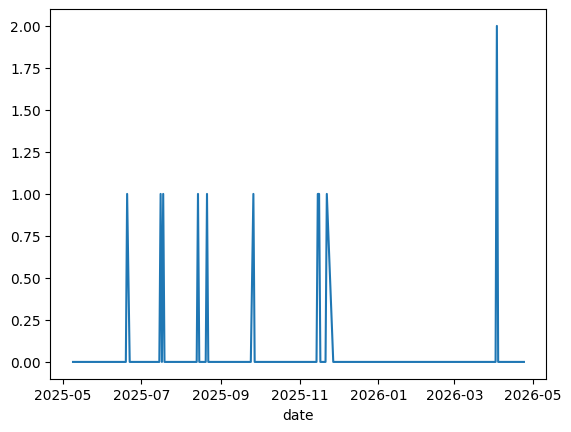

In [20]:
df["scam_flag"] = df["clean_text"].str.contains("scam", case=False, na=False)
df.groupby(df["date"].dt.date)["scam_flag"].sum().plot()

In [21]:
df[df["scam_flag"]].sort_values("date")[["date", "clean_text"]]

,date,clean_text
101,2025-06-20 20:24:15,"Dear Wiki Cat Holders,\n\nDuring the previous ..."
145,2025-07-16 10:52:42,"['Wiki Cat ', {'type': 'cashtag', 'text': '$WK..."
154,2025-07-18 10:16:36,['A token called MELEGA was airdropped to BNB ...
272,2025-08-14 09:52:19,I can't find anything on this exchange. There ...
300,2025-08-21 00:35:00,I’m glad to see that only a few reports of hol...
393,2025-09-26 10:29:21,"GM Believers,\nWiki Cat is too expensive for a..."
531,2025-11-15 08:25:51,"For the outrageous balance, I’m about to have ..."
539,2025-11-16 10:04:13,"['For those who waiting to buy the dip with ',..."
552,2025-11-22 10:40:58,"['Update on ', {'type': 'mention', 'text': '@p..."
667,2026-04-03 18:48:07,This is why I decided to take Wiki Cat communi...


In [22]:
daily_data = pd.DataFrame({
    "messages": messages_daily,
    "sentiment": sentiment_daily,
    "scam": df.groupby(df["date"].dt.date)["scam_flag"].sum()
}).fillna(0)

NameError: name 'messages_daily' is not defined

In [1]:
messages_daily = df.groupby(df["date"].dt.date).size()

sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()

NameError: name 'df' is not defined

In [2]:
daily_data = pd.DataFrame({
    "messages": messages_daily,
    "sentiment": sentiment_daily,
    "scam": df.groupby(df["date"].dt.date)["scam_flag"].sum()
}).fillna(0)


NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

In [4]:
import os
os.listdir()

['.cache',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.python_history',
 '.vscode',
 'analysis_plot.png',
 'AppData',
 'Application Data',
 'bybit_africa_messages.csv',
 'bybit_sample.csv',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{4f859de3-eff7-11ee-8421-a01d48e5ee06}.TxR.0.regtrans-ms',
 'NTUSER.DAT{4f859de3-eff7-11ee-8421-a01d48e5ee06}.TxR.1.regtrans-ms',
 'NTUSER.DAT{4f859de3-eff7-11ee-8421-a01d48e5ee06}.TxR.2.regtrans-ms',
 'NTUSER.DAT{4f859de3-eff7-11ee-8421-a01d48e5ee06}.TxR.blf',
 'NTUSER.DAT{4f859de4-eff7-11ee-8421-a01d48e5ee06}.TM.blf',
 'NTUSER.DAT{4f859de4-eff7-11ee-8421-a01d48e5ee06}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{4f859de4-eff7-11ee-8421-a01d48e5ee06}.TMContainer00000000000000000002.regtrans-ms',
 'NTUSER.DAT{53dc820f-23d4-11f1-8451-a01d48e5ee06}.TxR.0

In [5]:
import json
import pandas as pd

file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["messages"])

df.head()

,id,type,date,date_unixtime,actor,actor_id,action,title,text,text_entities,...,height,file,file_size,thumbnail,thumbnail_file_size,media_type,mime_type,duration_seconds,file_name,poll
0,1,service,2025-05-09T08:17:33,1746775053,Sir Mapy,channel2696454823,create_channel,Sir Mapy,,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,message,2025-05-09T12:25:17,1746789917,NaN,NaN,NaN,NaN,"[Believers,\nPlease look at for these dates 17...","[{'type': 'plain', 'text': 'Believers, Please ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4,message,2025-05-09T12:25:30,1746789930,NaN,NaN,NaN,NaN,"[Believers,\nIn light of the many warnings and...","[{'type': 'plain', 'text': 'Believers, In ligh...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,message,2025-05-09T12:25:46,1746789946,NaN,NaN,NaN,NaN,"[Believers,\nIn continuation of where I stoppe...","[{'type': 'plain', 'text': 'Believers, In cont...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,message,2025-05-09T13:03:14,1746792194,NaN,NaN,NaN,NaN,"Believers,\nWiki Cat's Market Cap and Supply d...","[{'type': 'plain', 'text': 'Believers, Wiki Ca...",...,800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
import json
import pandas as pd

file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["messages"])

In [7]:
print(df.head())

   id     type                 date date_unixtime     actor  \
0   1  service  2025-05-09T08:17:33    1746775053  Sir Mapy   
1   3  message  2025-05-09T12:25:17    1746789917       NaN   
2   4  message  2025-05-09T12:25:30    1746789930       NaN   
3   5  message  2025-05-09T12:25:46    1746789946       NaN   
4   6  message  2025-05-09T13:03:14    1746792194       NaN   

            actor_id          action     title  \
0  channel2696454823  create_channel  Sir Mapy   
1                NaN             NaN       NaN   
2                NaN             NaN       NaN   
3                NaN             NaN       NaN   
4                NaN             NaN       NaN   

                                                text  \
0                                                      
1  [Believers,\nPlease look at for these dates 17...   
2  [Believers,\nIn light of the many warnings and...   
3  [Believers,\nIn continuation of where I stoppe...   
4  Believers,\nWiki Cat's Market Cap and

In [8]:
df["clean_text"] = df["text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [9]:
from textblob import TextBlob

def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

df["sentiment"] = df["clean_text"].apply(get_sentiment)

In [10]:
df["scam_flag"] = df["clean_text"].str.contains(
    "scam|scams|scammed|scamming",
    case=False,
    na=False
)

In [11]:
messages_daily = df.groupby(df["date"].dt.date).size()
sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()
scam_daily = df.groupby(df["date"].dt.date)["scam_flag"].sum()

In [12]:
messages_daily.head()

date
2025-05-09    5
2025-05-10    3
2025-05-11    3
2025-05-12    2
2025-05-13    3
dtype: int64

In [13]:
sentiment_daily.head()

date
2025-05-09    0.061450
2025-05-10    0.194786
2025-05-11    0.208333
2025-05-12    0.185938
2025-05-13   -0.081134
Name: sentiment, dtype: float64

In [14]:
scam_daily.head()

date
2025-05-09    0
2025-05-10    0
2025-05-11    0
2025-05-12    0
2025-05-13    0
Name: scam_flag, dtype: int64

In [15]:
daily_data = pd.DataFrame({
    "messages": messages_daily,
    "sentiment": sentiment_daily,
    "scam": scam_daily
}).fillna(0)

In [16]:
daily_data["controversy"] = (
    (daily_data["messages"] / daily_data["messages"].max()) * 0.5 +
    (-daily_data["sentiment"]) * 0.3 +
    (daily_data["scam"] / (daily_data["scam"].max() + 1)) * 0.2
)

In [17]:
daily_data.sort_values("controversy", ascending=False).head(12)

,messages,sentiment,scam,controversy
date,,,,
2025-09-06,12,0.107924,0,0.467623
2025-08-12,11,0.031313,0,0.448939
2025-06-07,11,0.160198,0,0.410274
2025-10-07,10,0.091222,0,0.389300
2025-11-15,8,0.080928,1,0.375722
2025-10-03,9,0.004698,0,0.373591
2025-07-24,10,0.150417,0,0.371542
2025-06-24,9,0.074840,0,0.352548
2025-10-24,9,0.093436,0,0.346969


<Axes: title={'center': 'Controversy Score Over Time'}, xlabel='date'>

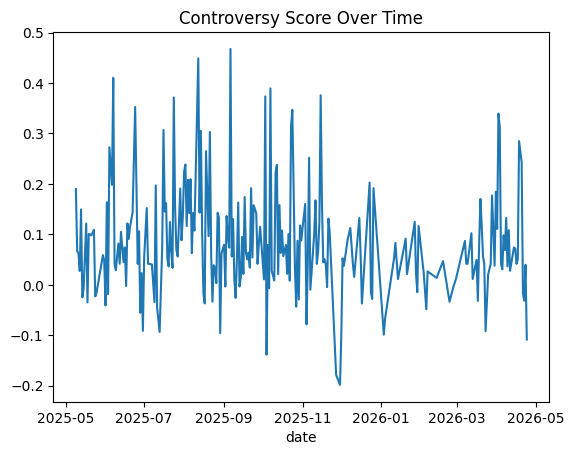

In [19]:
daily_data["controversy"].plot(title="Controversy Score Over Time")

In [1]:
threshold = daily_data["controversy"].mean() + daily_data["controversy"].std()

daily_data["alert"] = daily_data["controversy"] > threshold

NameError: name 'daily_data' is not defined

In [2]:
import json
import pandas as pd

file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["messages"])

In [3]:
df["date"] = pd.to_datetime(df["date"])

In [4]:
df["scam_flag"] = df["clean_text"].str.contains(
    "scam|scams|scammed|scamming",
    case=False,
    na=False
)

KeyError: 'clean_text'

In [5]:
import re

df["clean_text"] = df["text"].astype(str).apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x.lower())
)


In [6]:
df["scam_flag"] = df["clean_text"].str.contains(
    "scam|scams|scammed|scamming",
    case=False,
    na=False
)

In [7]:
messages_daily = df.groupby(df["date"].dt.date).size()
sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()
scam_daily = df.groupby(df["date"].dt.date)["scam_flag"].sum()

KeyError: 'Column not found: sentiment'

In [8]:
from textblob import TextBlob

def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

df["sentiment"] = df["text"].astype(str).apply(get_sentiment)

In [9]:
df["scam_flag"] = df["text"].astype(str).str.contains(
    "scam|scams|scammed|scamming",
    case=False,
    na=False
)

In [10]:
messages_daily = df.groupby(df["date"].dt.date).size()

sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()

scam_daily = df.groupby(df["date"].dt.date)["scam_flag"].sum()

In [11]:
print(df.columns)

Index(['id', 'type', 'date', 'date_unixtime', 'actor', 'actor_id', 'action',
       'title', 'text', 'text_entities', 'edited', 'edited_unixtime', 'from',
       'from_id', 'reactions', 'forwarded_from', 'forwarded_from_id', 'photo',
       'photo_file_size', 'width', 'height', 'file', 'file_size', 'thumbnail',
       'thumbnail_file_size', 'media_type', 'mime_type', 'duration_seconds',
       'file_name', 'poll', 'clean_text', 'scam_flag', 'sentiment'],
      dtype='str')


In [12]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [13]:
messages_daily = df.groupby(df["date"].dt.date).size()

sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()

scam_daily = df.groupby(df["date"].dt.date)["scam_flag"].sum()

In [14]:
print(messages_daily.head())

date
2025-05-09    7
2025-05-10    3
2025-05-11    3
2025-05-12    2
2025-05-13    3
dtype: int64


In [15]:
print(messages_daily.index.min())
print(messages_daily.index.max())

2025-05-09
2026-04-24


In [16]:
messages_daily.sample(15)

date
2025-07-20    2
2025-08-25    2
2026-04-10    3
2025-12-23    5
2026-03-19    3
2025-10-12    7
2025-10-26    1
2025-11-27    1
2025-09-03    3
2026-04-24    1
2026-01-20    1
2025-05-10    3
2025-07-15    3
2025-12-16    2
2025-09-27    1
dtype: int64

<Axes: title={'center': 'Messages Over Time'}, xlabel='date'>

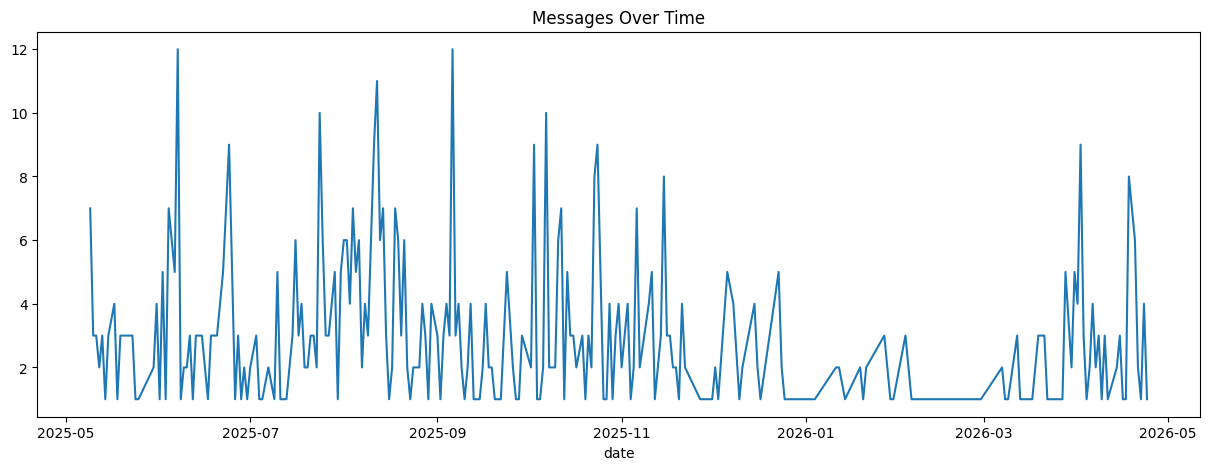

In [17]:
messages_daily.plot(figsize=(15,5),title="Messages Over Time")

In [18]:
daily_data["msg_spike"] = daily_data["messages"] > daily_data["messages"].mean() + daily_data["messages"].std()

daily_data["scam_spike"] = daily_data["scam"] > 0

daily_data["alert"] = (
    (daily_data["msg_spike"]) &
    (daily_data["controversy"] > daily_data["controversy"].mean()) |
    (daily_data["scam_spike"])
)


NameError: name 'daily_data' is not defined

In [19]:
import pandas as pd

In [20]:
df = pd.DataFrame(data["messages"])

In [21]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [22]:
messages_daily = df.groupby(df["date"].dt.date).size()
sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()
scam_daily = df.groupby(df["date"].dt.date)["scam_flag"].sum()

KeyError: 'Column not found: sentiment'

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

file_path = r"C:\Users\Lavatoz\TelegramData\sir_mapy.json.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data["messages"])

In [2]:
df["clean_text"] = df["text"].astype(str)
df = df[df["clean_text"].str.strip() != ""]
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [3]:
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

df["sentiment"] = df["clean_text"].apply(get_sentiment)

df["scam_flag"] = df["clean_text"].str.contains(
    "scam|scams|scammed|scamming|rug|fake|fraud|ponzi|suspicious",
    case=False,
    na=False
)

In [4]:
messages_daily = df.groupby(df["date"].dt.date).size()
sentiment_daily = df.groupby(df["date"].dt.date)["sentiment"].mean()
scam_daily = df.groupby(df["date"].dt.date)["scam_flag"].sum()

daily_data = pd.DataFrame({
    "messages": messages_daily,
    "sentiment": sentiment_daily,
    "scam": scam_daily
}).fillna(0)

daily_data.head()

,messages,sentiment,scam
date,,,
2025-05-09,5,0.061450,0
2025-05-10,3,0.194786,0
2025-05-11,3,0.208333,0
2025-05-12,2,0.185938,0
2025-05-13,3,-0.081134,0


In [5]:
daily_data["controversy"] = daily_data["sentiment"].abs()

In [6]:
daily_data["msg_spike"] = daily_data["messages"] > (
    daily_data["messages"].mean() + daily_data["messages"].std()
)

In [7]:
daily_data["scam_spike"] = daily_data["scam"] > 0

In [8]:
daily_data["alert"] = (
    (daily_data["msg_spike"] & (daily_data["controversy"] > daily_data["controversy"].mean()))
    | daily_data["scam_spike"]
)

In [9]:
daily_data[daily_data["alert"] == True]

,messages,sentiment,scam,controversy,msg_spike,scam_spike,alert
date,,,,,,,
2025-06-07,11,0.160198,0,0.160198,True,False,True
2025-06-20,3,0.255821,1,0.255821,False,True,True
2025-07-01,2,0.096162,1,0.096162,False,True,True
2025-07-16,6,0.032646,1,0.032646,True,True,True
2025-07-18,4,0.237882,1,0.237882,False,True,True
2025-08-04,7,0.278307,0,0.278307,True,False,True
2025-08-09,3,0.058260,1,0.058260,False,True,True
2025-08-14,7,0.176497,1,0.176497,True,True,True
2025-08-19,5,0.081895,1,0.081895,False,True,True


In [10]:
daily_data["alert"] = (
    (daily_data["msg_spike"] & daily_data["high_controversy"]) |
    (daily_data["scam_spike"] & daily_data["msg_spike"])
)

KeyError: 'high_controversy'

In [11]:
daily_data["high_controversy"] = daily_data["controversy"] > (
    daily_data["controversy"].mean() + daily_data["controversy"].std()
)

In [12]:
daily_data["alert"] = (
    (daily_data["msg_spike"] & daily_data["high_controversy"]) |
    (daily_data["scam_spike"] & daily_data["msg_spike"])
)

In [13]:
print(daily_data.columns)

Index(['messages', 'sentiment', 'scam', 'controversy', 'msg_spike',
       'scam_spike', 'alert', 'high_controversy'],
      dtype='str')


In [14]:
daily_data["scam"].sum()

np.int64(21)

In [15]:
daily_data[daily_data["scam"] > 0]

,messages,sentiment,scam,controversy,msg_spike,scam_spike,alert,high_controversy
date,,,,,,,,
2025-06-20,3,0.255821,1,0.255821,False,True,False,False
2025-07-01,2,0.096162,1,0.096162,False,True,False,False
2025-07-16,6,0.032646,1,0.032646,True,True,True,False
2025-07-18,4,0.237882,1,0.237882,False,True,False,False
2025-08-09,3,0.058260,1,0.058260,False,True,False,False
2025-08-14,7,0.176497,1,0.176497,True,True,True,False
2025-08-19,5,0.081895,1,0.081895,False,True,False,False
2025-08-21,6,0.044932,1,0.044932,True,True,True,False
2025-09-17,4,-0.024574,1,0.024574,False,True,False,False


In [16]:
df[df["scam_flag"]][["date", "clean_text"]].sort_values("date")

,date,clean_text
101,2025-06-20 20:24:15,"Dear Wiki Cat Holders,\n\nDuring the previous ..."
125,2025-07-01 21:14:21,If you are a Believer into medical sciences an...
145,2025-07-16 10:52:42,"['Wiki Cat ', {'type': 'cashtag', 'text': '$WK..."
154,2025-07-18 10:16:36,['A token called MELEGA was airdropped to BNB ...
242,2025-08-09 11:03:46,"Believers,\nAfter 2 failed attempt, we have fi..."
272,2025-08-14 09:52:19,I can't find anything on this exchange. There ...
292,2025-08-19 11:16:44,Someone created a fake Wiki Cat and airdropped...
300,2025-08-21 00:35:00,I’m glad to see that only a few reports of hol...
375,2025-09-17 10:54:41,"['Update on ', {'type': 'mention', 'text': '@P..."
393,2025-09-26 10:29:21,"GM Believers,\nWiki Cat is too expensive for a..."


In [17]:
def classify_scam(text):
    text = str(text).lower()
    
    if "not a scam" in text:
        return "defense"
    elif "fake" in text or "exit" in text or "withdraw" in text:
        return "warning"
    elif "scam" in text:
        return "accusation"
    else:
        return "other"

df["scam_type"] = df["clean_text"].apply(classify_scam)

In [18]:
df[df["scam_flag"]]["scam_type"].value_counts()

scam_type
accusation    8
warning       8
other         5
Name: count, dtype: int64

In [19]:
df["scam_type"].value_counts(normalize=True)

scam_type
other         0.968345
warning       0.020144
accusation    0.011511
Name: proportion, dtype: float64

In [20]:
df[df["scam_flag"]]["scam_type"].value_counts(normalize=True)

scam_type
accusation    0.380952
warning       0.380952
other         0.238095
Name: proportion, dtype: float64